# Import Library & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [2]:
np.random.seed(42)

# LOAD DATA
df_a = pd.read_csv('merge_DocLab_Clean.csv')   # Group A: original
df_b = pd.read_csv('merge_DocLab_hybrid.csv')  # Group B: Oversampling

# Konversi NM_UNIT ke int
df_a['NM_UNIT'] = df_a['NM_UNIT'].astype(int)
df_b['NM_UNIT'] = df_b['NM_UNIT'].astype(int)

FEATURES = ['JENIS_KELAMIN', 'UMUR_TAHUN', 'cholesterol total', 'creatinin',
            'fbs', 'rbs', 'hgb', 'lymfosit%', 'mch', 'mchc', 'mcv', 'ureum', 'wbc']
TARGET = 'NM_UNIT'
LABEL_MAP = {0: 'Normal', 1: 'Jantung', 2: 'Peny.Dalam', 3: 'Paru'}

print("RINGKASAN DATASET")
print(f"{'':25} {'Group A':>12} {'Group B':>12}")
print(f"{'':25} {'(Original)':>12} {'(Hybrid)':>12}")
print("-" * 50)
print(f"{'Total baris':<25} {len(df_a):>12} {len(df_b):>12}")
print(f"{'Total missing':<25} {df_a.isnull().sum().sum():>12} {df_b.isnull().sum().sum():>12}")
for u, label in LABEL_MAP.items():
    na = (df_a[TARGET] == u).sum()
    nb = (df_b[TARGET] == u).sum()
    print(f"  {label:<23} {na:>12} {nb:>12}")



RINGKASAN DATASET
                               Group A      Group B
                            (Original)     (Hybrid)
--------------------------------------------------
Total baris                       6430         6430
Total missing                    58816            0
  Normal                          2173         2173
  Jantung                          914          914
  Peny.Dalam                      2698         2698
  Paru                             645          645


# Build Model


In [3]:
# Group A — pipeline dengan imputer
pipe_a = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42,
                                   class_weight='balanced'))
])

# Group B — langsung RF
pipe_b = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42,
                                   class_weight='balanced'))
])

X_a, y_a = df_a[FEATURES], df_a[TARGET]
X_b, y_b = df_b[FEATURES], df_b[TARGET]



# Cross Validation

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("CROSS VALIDATION — 5-Fold Stratified")

results = {}
for name, pipe, X, y in [('Group A (Original)', pipe_a, X_a, y_a),
                          ('Group B (Hybrid)',   pipe_b, X_b, y_b)]:
    acc  = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    f1w  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_weighted')
    f1m  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
    results[name] = {'accuracy': acc, 'f1_weighted': f1w, 'f1_macro': f1m}
    print(f"\n  {name}")
    print(f"  Accuracy   : {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"  F1-weighted: {f1w.mean():.4f} ± {f1w.std():.4f}")
    print(f"  F1-macro   : {f1m.mean():.4f} ± {f1m.std():.4f}")



CROSS VALIDATION — 5-Fold Stratified

  Group A (Original)
  Accuracy   : 0.6266 ± 0.0144
  F1-weighted: 0.6426 ± 0.0141
  F1-macro   : 0.5514 ± 0.0121

  Group B (Hybrid)
  Accuracy   : 0.9365 ± 0.0063
  F1-weighted: 0.9360 ± 0.0064
  F1-macro   : 0.9087 ± 0.0090


# Evaluation

## Statistic t-test

In [5]:
# Apakah perbedaan signifikan? (p < 0.05 = signifikan)
print("UJI STATISTIK — Paired t-test (CV scores)")

for metric in ['accuracy', 'f1_weighted', 'f1_macro']:
    scores_a = results['Group A (Original)'][metric]
    scores_b = results['Group B (Hybrid)'][metric]
    t_stat, p_val = stats.ttest_rel(scores_a, scores_b)
    sig = "✅ Signifikan" if p_val < 0.05 else "❌ Tidak Signifikan"
    delta = scores_b.mean() - scores_a.mean()
    print(f"\n  {metric}")
    print(f"  Δ (B - A) : {delta:+.4f}")
    print(f"  t-stat    : {t_stat:.4f}")
    print(f"  p-value   : {p_val:.4f}  → {sig} (α=0.05)")



UJI STATISTIK — Paired t-test (CV scores)

  accuracy
  Δ (B - A) : +0.3100
  t-stat    : -42.6707
  p-value   : 0.0000  → ✅ Signifikan (α=0.05)

  f1_weighted
  Δ (B - A) : +0.2934
  t-stat    : -43.3522
  p-value   : 0.0000  → ✅ Signifikan (α=0.05)

  f1_macro
  Δ (B - A) : +0.3573
  t-stat    : -50.5318
  p-value   : 0.0000  → ✅ Signifikan (α=0.05)


## Train-Test Split Evaluation

EVALUASI TRAIN/TEST SPLIT (80:20)

  Group A (Original)
              precision    recall  f1-score   support

      Normal      1.000     1.000     1.000       435
     Jantung      0.310     0.415     0.355       183
  Peny.Dalam      0.707     0.421     0.528       539
        Paru      0.249     0.550     0.343       129

    accuracy                          0.629      1286
   macro avg      0.567     0.597     0.557      1286
weighted avg      0.704     0.629     0.644      1286


  Group B (Hybrid)
              precision    recall  f1-score   support

      Normal      1.000     1.000     1.000       435
     Jantung      0.816     0.776     0.796       183
  Peny.Dalam      0.929     0.950     0.939       539
        Paru      0.921     0.899     0.910       129

    accuracy                          0.937      1286
   macro avg      0.916     0.906     0.911      1286
weighted avg      0.936     0.937     0.936      1286



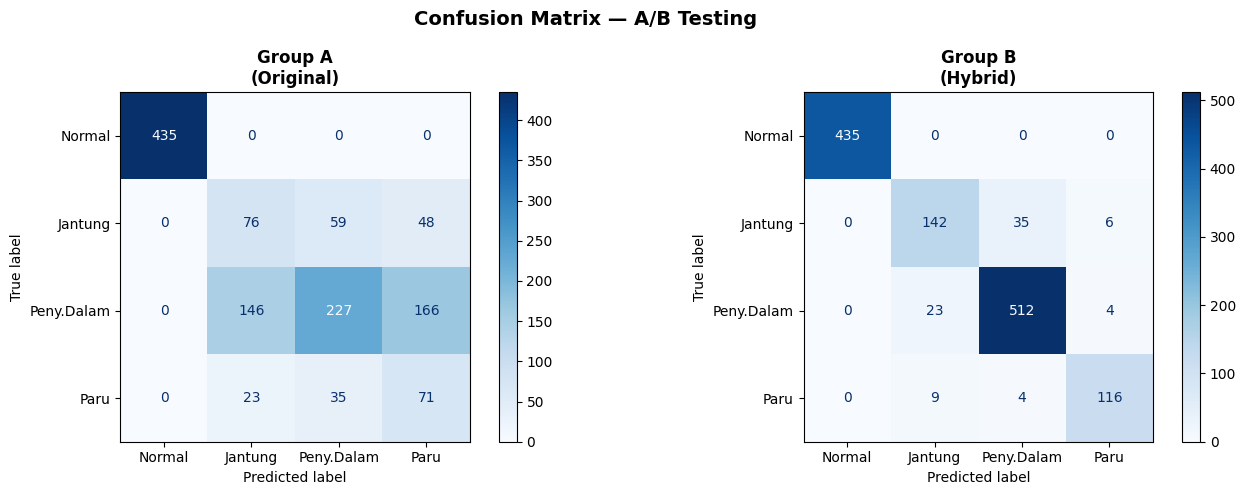

In [6]:
print("EVALUASI TRAIN/TEST SPLIT (80:20)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, pipe, X, y) in enumerate([
    ('Group A\n(Original)', pipe_a, X_a, y_a),
    ('Group B\n(Hybrid)',   pipe_b, X_b, y_b)
]):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n  {name.replace(chr(10), ' ')}")
    print(classification_report(y_test, y_pred,
          target_names=list(LABEL_MAP.values()), digits=3))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=list(LABEL_MAP.values()),
        cmap='Blues', ax=axes[i]
    )
    axes[i].set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix — A/B Testing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisasi


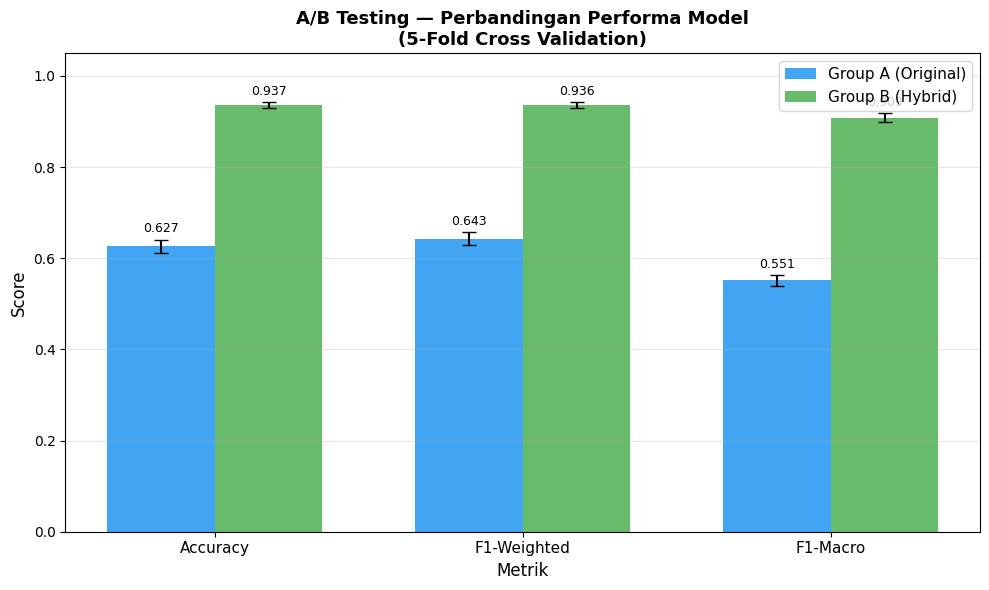

In [7]:
metrics   = ['accuracy', 'f1_weighted', 'f1_macro']
labels    = ['Accuracy', 'F1-Weighted', 'F1-Macro']
means_a   = [results['Group A (Original)'][m].mean() for m in metrics]
means_b   = [results['Group B (Hybrid)'][m].mean() for m in metrics]
stds_a    = [results['Group A (Original)'][m].std() for m in metrics]
stds_b    = [results['Group B (Hybrid)'][m].std() for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_a = ax.bar(x - width/2, means_a, width, yerr=stds_a, label='Group A (Original)',
                color='#2196F3', alpha=0.85, capsize=5)
bars_b = ax.bar(x + width/2, means_b, width, yerr=stds_b, label='Group B (Hybrid)',
                color='#4CAF50', alpha=0.85, capsize=5)

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('A/B Testing — Perbandingan Performa Model\n(5-Fold Cross Validation)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.bar_label(bars_a, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars_b, fmt='%.3f', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [8]:
print("KESIMPULAN A/B TESTING")

for metric, label in zip(metrics, labels):
    ma = results['Group A (Original)'][metric].mean()
    mb = results['Group B (Hybrid)'][metric].mean()
    winner = 'Group B (Hybrid)' if mb > ma else 'Group A (Original)'
    delta  = abs(mb - ma)
    _, p   = stats.ttest_rel(
        results['Group A (Original)'][metric],
        results['Group B (Hybrid)'][metric]
    )
    sig = 'signifikan' if p < 0.05 else 'tidak signifikan'
    print(f"\n  {label}:")
    print(f"    A={ma:.4f} | B={mb:.4f} | Δ={delta:.4f}")
    print(f"    Pemenang: {winner} (perbedaan {sig}, p={p:.4f})")

KESIMPULAN A/B TESTING

  Accuracy:
    A=0.6266 | B=0.9365 | Δ=0.3100
    Pemenang: Group B (Hybrid) (perbedaan signifikan, p=0.0000)

  F1-Weighted:
    A=0.6426 | B=0.9360 | Δ=0.2934
    Pemenang: Group B (Hybrid) (perbedaan signifikan, p=0.0000)

  F1-Macro:
    A=0.5514 | B=0.9087 | Δ=0.3573
    Pemenang: Group B (Hybrid) (perbedaan signifikan, p=0.0000)
